# Basic Market Analysis

Descriptive market analysis built on cached derived tables. The notebook focuses on distributions, returns, volatility, spreads, and trade activity.

Scope:
- descriptive diagnostics only
- no predictive modeling
- no OFI or cancel-like proxies

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
def find_backtester_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "stats").is_dir() and (candidate / "notebooks").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the exchange-data-backtester project root")


def resolve_day_dir(project_root: Path, *, symbol: str, day: str) -> Path:
    candidates = [
        project_root.parent / "exchange-data-recorder" / "data" / symbol / day,
        project_root.parent / "exchange-data-recorder" / "data" / "binance" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / "binance" / symbol / day,
        Path("../exchange-data-recorder/data") / symbol / day,
        Path("../exchange-data-recorder/data/binance") / symbol / day,
        project_root / "data" / symbol / day,
        project_root / "data" / "binance" / symbol / day,
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / "schema.json").is_file():
            return candidate
    raise FileNotFoundError(f"Could not locate a recorder day folder for {symbol}/{day}")


PROJECT_ROOT = find_backtester_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-backtester')

In [3]:
symbol = "BTCUSDC"
day = "20260222"
grid_freq = "1s"
return_horizons = ["1s", "5s", "30s", "1min"]
vol_window = "5min"
replay_on_gap = "skip-segment"

day_dir = resolve_day_dir(PROJECT_ROOT, symbol=symbol, day=day)
day_dir

PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-recorder/data/binance/BTCUSDC/20260222')

In [4]:
from stats.io import load_day
from stats.notebook import replay_summary
from stats.tables import get_or_build_market_grid, get_or_build_top_of_book_table, get_or_build_trades_table

dataset = load_day(day_dir)
replay_info = replay_summary(dataset, replay_on_gap=replay_on_gap)
top_of_book = get_or_build_top_of_book_table(dataset, on_gap=replay_on_gap)
trades = get_or_build_trades_table(dataset)
market_grid = get_or_build_market_grid(dataset, grid_freq=grid_freq, on_gap=replay_on_gap)

dataset

In [5]:
def fmt_ts(ts: pd.Timestamp | float | int | None) -> str:
    if ts is None or (isinstance(ts, float) and np.isnan(ts)):
        return "n/a"
    if not isinstance(ts, pd.Timestamp):
        ts = pd.Timestamp(ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    return ts.strftime("%Y-%m-%d %H:%M:%S %Z")


summary = pd.DataFrame(
    {
        "field": [
            "exchange",
            "symbol",
            "day",
            "grid_freq",
            "replay_on_gap",
            "segments_total",
            "segments_kept",
            "segments_skipped",
            "book_from",
            "book_to",
            "trade_from",
            "trade_to",
            "book_rows",
            "trade_rows",
            "grid_rows",
            "total_qty",
            "total_notional",
            "median_spread_bps",
            "mean_spread_bps",
            "valid_book_share",
        ],
        "value": [
            dataset.exchange,
            dataset.symbol,
            dataset.day,
            grid_freq,
            replay_info["replay_on_gap"],
            replay_info["segments_total"],
            replay_info["segments_kept"],
            replay_info["segments_skipped"],
            fmt_ts(top_of_book["ts"].min() if not top_of_book.empty else None),
            fmt_ts(top_of_book["ts"].max() if not top_of_book.empty else None),
            fmt_ts(trades["ts"].min() if not trades.empty else None),
            fmt_ts(trades["ts"].max() if not trades.empty else None),
            len(top_of_book),
            len(trades),
            len(market_grid),
            float(trades["qty"].sum()) if not trades.empty else 0.0,
            float(trades["notional"].sum()) if not trades.empty else 0.0,
            float(top_of_book["spread_bps"].median()) if not top_of_book.empty else np.nan,
            float(top_of_book["spread_bps"].mean()) if not top_of_book.empty else np.nan,
            float(market_grid["valid_book"].mean()) if "valid_book" in market_grid.columns else np.nan,
        ],
    }
)
summary

,field,value
0,exchange,binance
1,symbol,BTCUSDC
2,day,20260222
3,grid_freq,1s
4,replay_on_gap,skip-segment
5,segments_total,1
6,segments_kept,1
7,segments_skipped,0
8,book_from,2026-02-22 14:59:04 UTC
9,book_to,2026-02-22 23:15:00 UTC


### Summary Guide

The table above is intentionally compact. This guide explains what each field means for someone who has not read the recorder code.

In [16]:
summary_guide = pd.DataFrame(
    {
        "field": [
            "exchange",
            "symbol",
            "day",
            "grid_freq",
            "replay_on_gap",
            "segments_total",
            "segments_kept",
            "segments_skipped",
            "book_from / book_to",
            "trade_from / trade_to",
            "book_rows",
            "trade_rows",
            "grid_rows",
            "total_qty",
            "total_notional",
            "median_spread_bps",
            "mean_spread_bps",
            "valid_book_share",
        ],
        "meaning": [
            "Exchange name from the dataset contract.",
            "Trading pair being analyzed.",
            "Recorder day folder. This is the recording date key, not necessarily UTC midnight.",
            "Sampling grid used for the derived market grid and rolling statistics.",
            "Replay policy for broken segments. `skip-segment` keeps valid segments and drops invalid ones.",
            "How many replay segments exist in the day.",
            "How many segments were replayable under the selected policy.",
            "How many segments were discarded or unavailable.",
            "Time span covered by the replayed top-of-book cache.",
            "Time span covered by the normalized trade cache.",
            "Number of replayed top-of-book rows kept in the cached table.",
            "Number of normalized trade prints kept in the cached table.",
            "Number of rows in the resampled analysis grid.",
            "Total traded quantity across the day, measured in the base asset of the symbol. For BTCUSDC, this is BTC.",
            "Total traded notional across the day, measured in the quote asset of the symbol. For BTCUSDC, this is USDC.",
            "Typical spread in basis points.",
            "Average spread in basis points across the day.",
            "Fraction of grid rows where the replayed book was valid.",
        ],
    }
)
summary_guide

,field,meaning
0,exchange,Exchange name from the dataset contract.
1,symbol,Trading pair being analyzed.
2,day,Recorder day folder. This is the recording dat...
3,grid_freq,Sampling grid used for the derived market grid...
4,replay_on_gap,Replay policy for broken segments. `skip-segme...
5,segments_total,How many replay segments exist in the day.
6,segments_kept,How many segments were replayable under the se...
7,segments_skipped,How many segments were discarded or unavailable.
8,book_from / book_to,Time span covered by the replayed top-of-book ...
9,trade_from / trade_to,Time span covered by the normalized trade cache.


## Price Basics

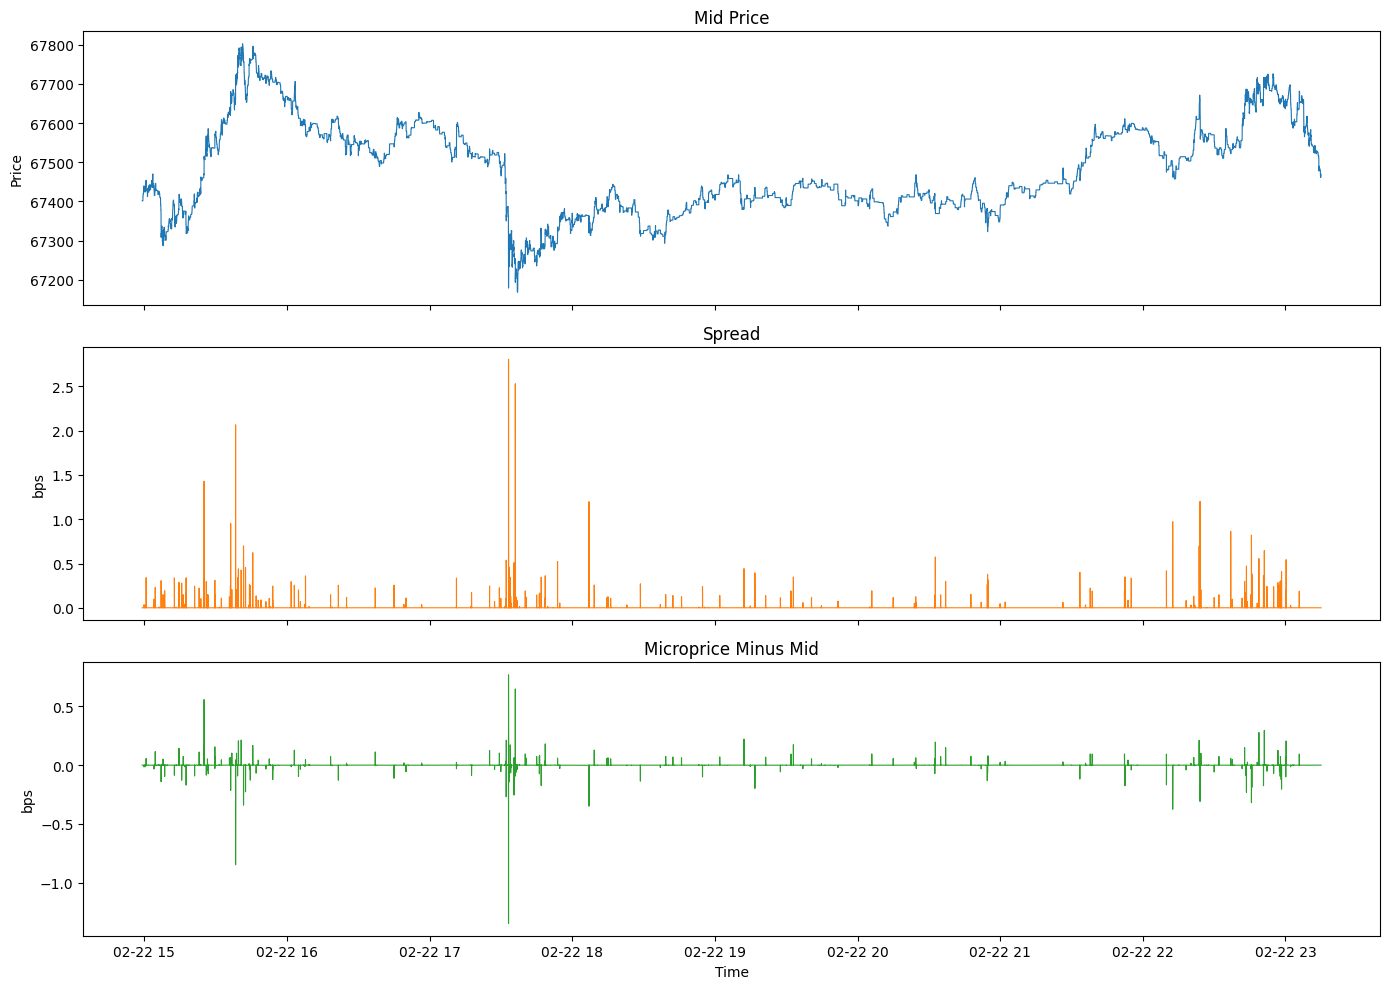

In [6]:
price_view = top_of_book[["ts", "mid", "spread_bps", "microprice"]].copy()
price_view["microprice_minus_mid_bps"] = 1e4 * (price_view["microprice"] - price_view["mid"]) / price_view["mid"]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(price_view["ts"], price_view["mid"], linewidth=0.8)
axes[0].set_title("Mid Price")
axes[0].set_ylabel("Price")

axes[1].plot(price_view["ts"], price_view["spread_bps"], linewidth=0.8, color="tab:orange")
axes[1].set_title("Spread")
axes[1].set_ylabel("bps")

axes[2].plot(price_view["ts"], price_view["microprice_minus_mid_bps"], linewidth=0.8, color="tab:green")
axes[2].set_title("Microprice Minus Mid")
axes[2].set_ylabel("bps")
axes[2].set_xlabel("Time")

fig.tight_layout()

## Return Analysis

In [7]:
from stats.features.returns import forward_returns

horizon_ms = [int(pd.Timedelta(h).total_seconds() * 1000) for h in return_horizons]
mid = market_grid["mid"].astype(float)
returns = forward_returns(mid, horizons_ms=horizon_ms, grid_freq=grid_freq, log=True)
returns.columns = [f"fwd_log_ret_{h}" for h in return_horizons]

step_returns = np.log(mid).diff()
event_returns = np.log(top_of_book["mid"]).diff() if not top_of_book.empty else pd.Series(dtype=float)

def summarize_series(name: str, series: pd.Series) -> dict[str, float | str]:
    clean = series.replace([np.inf, -np.inf], np.nan).dropna()
    if clean.empty:
        return {"series": name, "count": 0}
    return {
        "series": name,
        "count": int(clean.shape[0]),
        "mean": float(clean.mean()),
        "std": float(clean.std()),
        "skew": float(clean.skew()),
        "kurtosis": float(clean.kurtosis()),
        "q01": float(clean.quantile(0.01)),
        "median": float(clean.median()),
        "q99": float(clean.quantile(0.99)),
        "zero_share": float((clean == 0).mean()),
    }


return_summary = pd.DataFrame(
    [summarize_series(f"event_log_ret", event_returns)]
    + [summarize_series(col, returns[col]) for col in returns.columns]
)
return_summary

,series,count,mean,std,skew,kurtosis,q01,median,q99,zero_share
0,event_log_ret,223763,4.482589e-09,0.000012,1.396362,721.865267,-0.000014,0.0,0.000015,0.973606
1,fwd_log_ret_1s,29756,3.370875e-08,0.000041,-4.906872,379.710452,-0.000134,0.0,0.000127,0.882780
2,fwd_log_ret_5s,29752,1.670868e-07,0.000097,-1.506891,53.409351,-0.000294,0.0,0.000294,0.641436
3,fwd_log_ret_30s,29727,9.443770e-07,0.000248,-0.735337,8.752876,-0.000720,0.0,0.000710,0.209574
4,fwd_log_ret_1min,29697,1.845638e-06,0.000340,-0.500321,4.372116,-0.001082,0.0,0.000935,0.069098


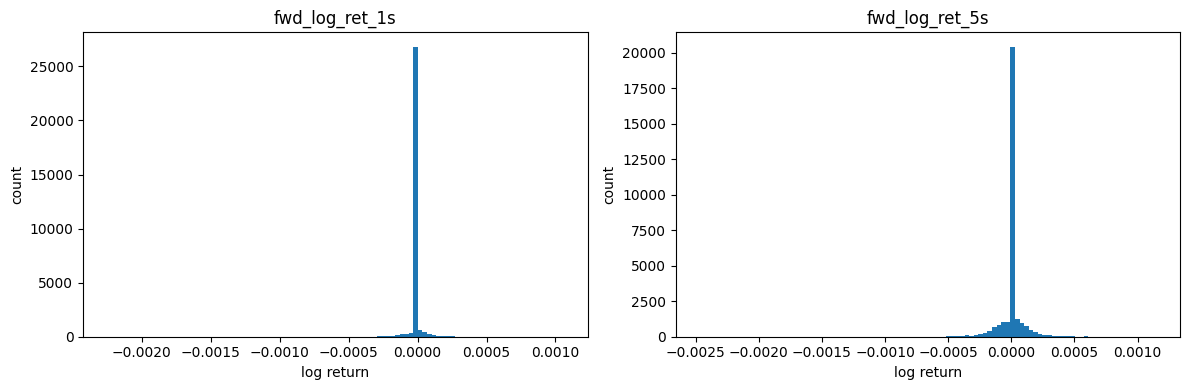

In [8]:
fig, axes = plt.subplots(1, min(2, len(returns.columns)), figsize=(12, 4))
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])
for ax, column in zip(axes, returns.columns[:2]):
    values = returns[column].dropna()
    ax.hist(values, bins=100)
    ax.set_title(column)
    ax.set_xlabel("log return")
    ax.set_ylabel("count")
fig.tight_layout()

## Volatility

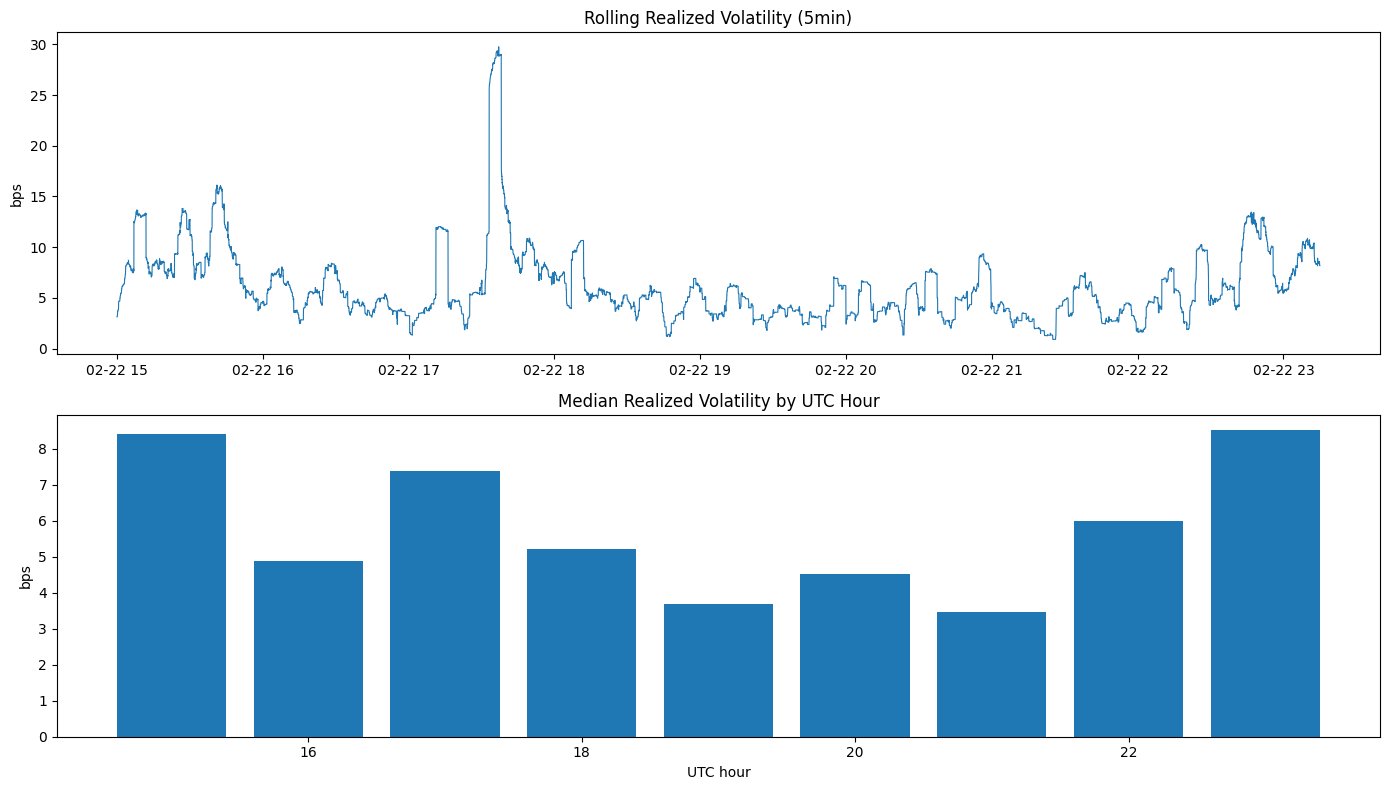

In [9]:
step = pd.Timedelta(grid_freq)
window_bars = max(1, int(pd.Timedelta(vol_window) / step))
rolling_rv = step_returns.pow(2).rolling(window_bars, min_periods=max(2, window_bars // 5)).sum().pow(0.5)
rolling_rv_bps = 1e4 * rolling_rv
vol_df = pd.DataFrame({"rv_bps": rolling_rv_bps})
vol_df["hour_utc"] = vol_df.index.hour
intraday_vol = vol_df.groupby("hour_utc")["rv_bps"].median()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(vol_df.index, vol_df["rv_bps"], linewidth=0.8)
axes[0].set_title(f"Rolling Realized Volatility ({vol_window})")
axes[0].set_ylabel("bps")

axes[1].bar(intraday_vol.index, intraday_vol.values, width=0.8)
axes[1].set_title("Median Realized Volatility by UTC Hour")
axes[1].set_xlabel("UTC hour")
axes[1].set_ylabel("bps")
fig.tight_layout()

## Trade Activity

In [10]:
trade_summary = pd.DataFrame(
    {
        "field": [
            "trade_count",
            "buy_share",
            "median_trade_qty",
            "p99_trade_qty",
            "median_notional",
            "signed_qty_sum",
            "signed_notional_sum",
        ],
        "value": [
            int(len(trades)),
            float((trades["aggr_sign"] > 0).mean()) if not trades.empty else np.nan,
            float(trades["qty"].median()) if not trades.empty else np.nan,
            float(trades["qty"].quantile(0.99)) if not trades.empty else np.nan,
            float(trades["notional"].median()) if not trades.empty else np.nan,
            float(trades["signed_qty"].sum()) if not trades.empty else np.nan,
            float(trades["signed_notional"].sum()) if not trades.empty else np.nan,
        ],
    }
)
trade_summary

,field,value
0,trade_count,72092.000000
1,buy_share,0.508503
2,median_trade_qty,0.000355
3,p99_trade_qty,0.157535
4,median_notional,23.969304
5,signed_qty_sum,12.582670
6,signed_notional_sum,838129.901433


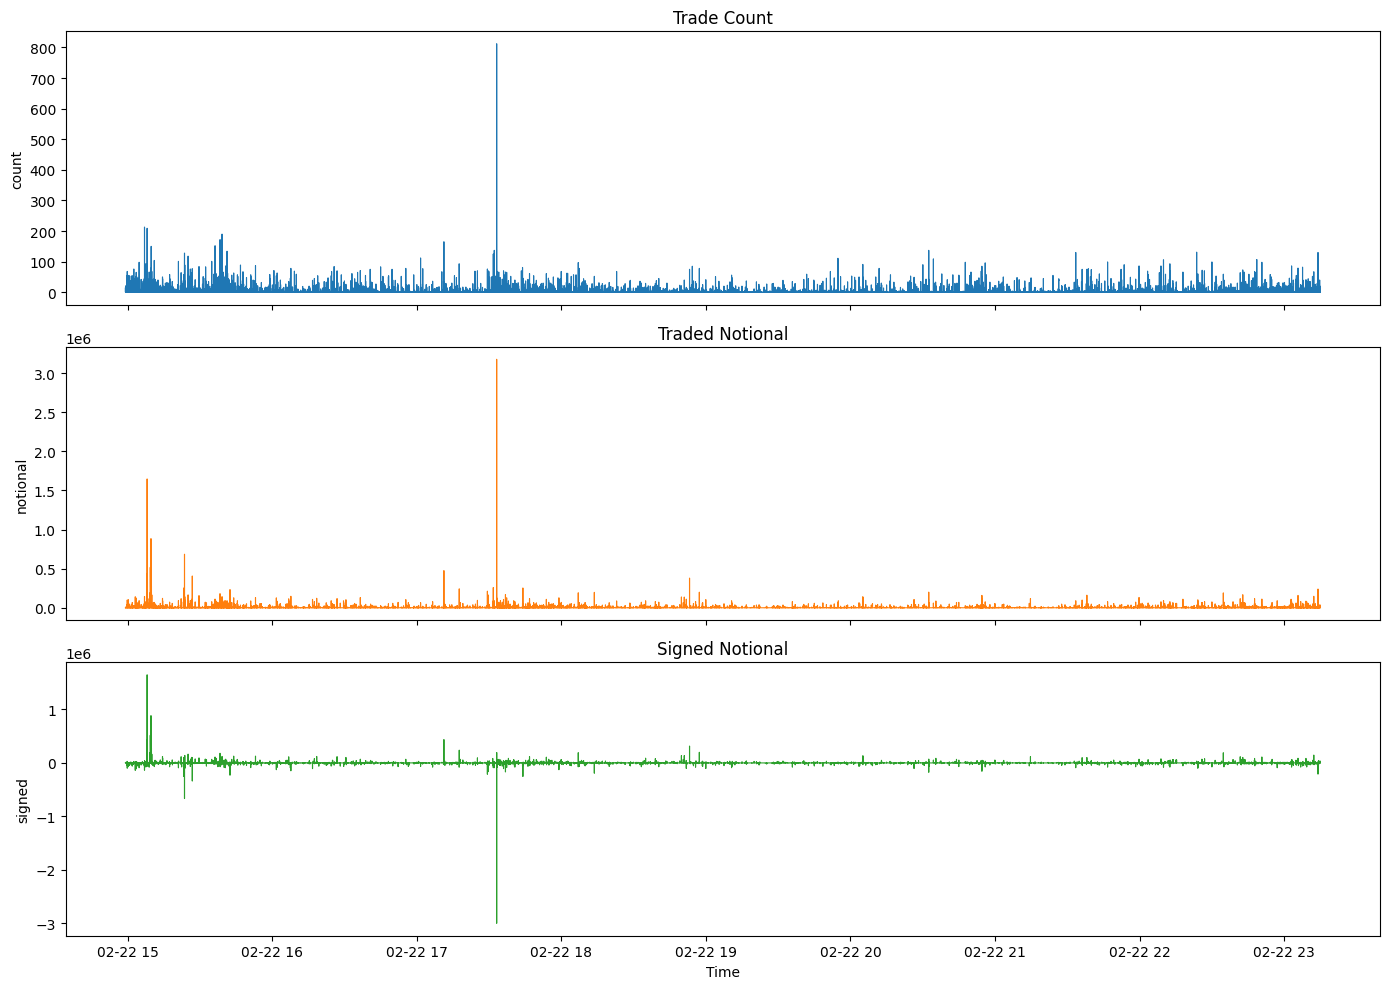

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(market_grid.index, market_grid["trade_count"].fillna(0), linewidth=0.8)
axes[0].set_title("Trade Count")
axes[0].set_ylabel("count")

axes[1].plot(market_grid.index, market_grid["total_notional"].fillna(0), linewidth=0.8, color="tab:orange")
axes[1].set_title("Traded Notional")
axes[1].set_ylabel("notional")

axes[2].plot(market_grid.index, market_grid["signed_notional"].fillna(0), linewidth=0.8, color="tab:green")
axes[2].set_title("Signed Notional")
axes[2].set_ylabel("signed")
axes[2].set_xlabel("Time")

fig.tight_layout()

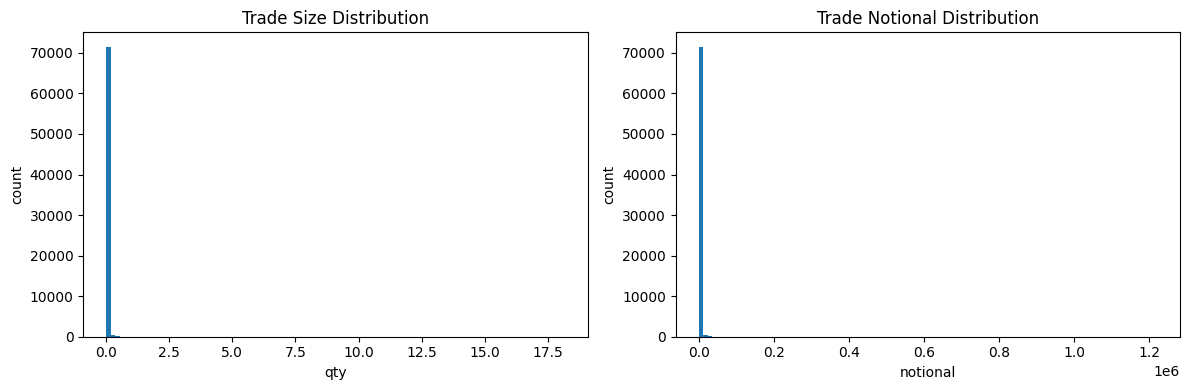

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(trades["qty"].dropna(), bins=100)
axes[0].set_title("Trade Size Distribution")
axes[0].set_xlabel("qty")
axes[0].set_ylabel("count")

axes[1].hist(trades["notional"].dropna(), bins=100)
axes[1].set_title("Trade Notional Distribution")
axes[1].set_xlabel("notional")
axes[1].set_ylabel("count")
fig.tight_layout()

## Book State

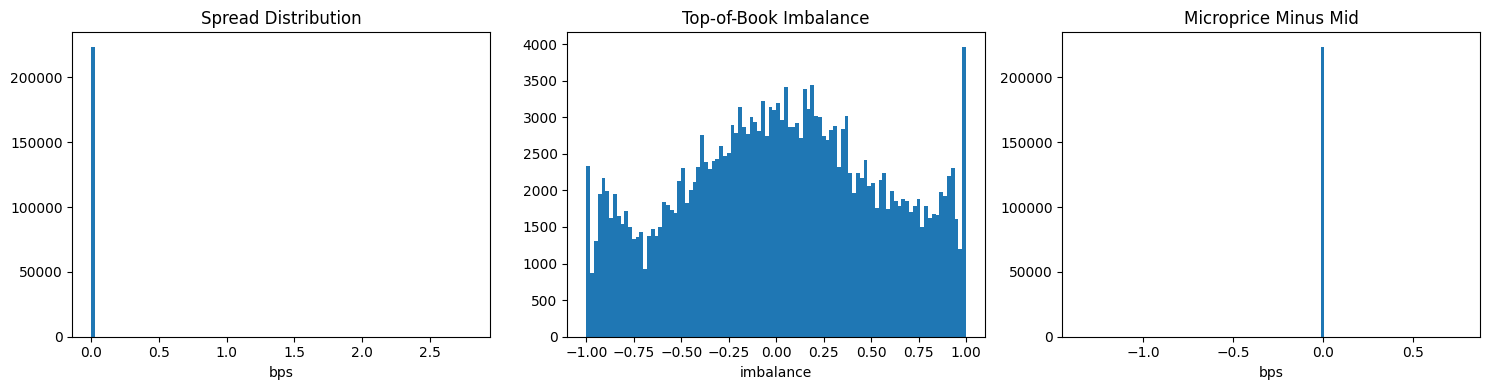

In [13]:
book_stats = top_of_book.copy()
book_stats["imbalance_1"] = (book_stats["bid1_qty"] - book_stats["ask1_qty"]) / (book_stats["bid1_qty"] + book_stats["ask1_qty"]).replace(0, np.nan)
book_stats["microprice_minus_mid_bps"] = 1e4 * (book_stats["microprice"] - book_stats["mid"]) / book_stats["mid"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(book_stats["spread_bps"].dropna(), bins=100)
axes[0].set_title("Spread Distribution")
axes[0].set_xlabel("bps")

axes[1].hist(book_stats["imbalance_1"].dropna(), bins=100)
axes[1].set_title("Top-of-Book Imbalance")
axes[1].set_xlabel("imbalance")

axes[2].hist(book_stats["microprice_minus_mid_bps"].dropna(), bins=100)
axes[2].set_title("Microprice Minus Mid")
axes[2].set_xlabel("bps")
fig.tight_layout()

## Simple Relationships

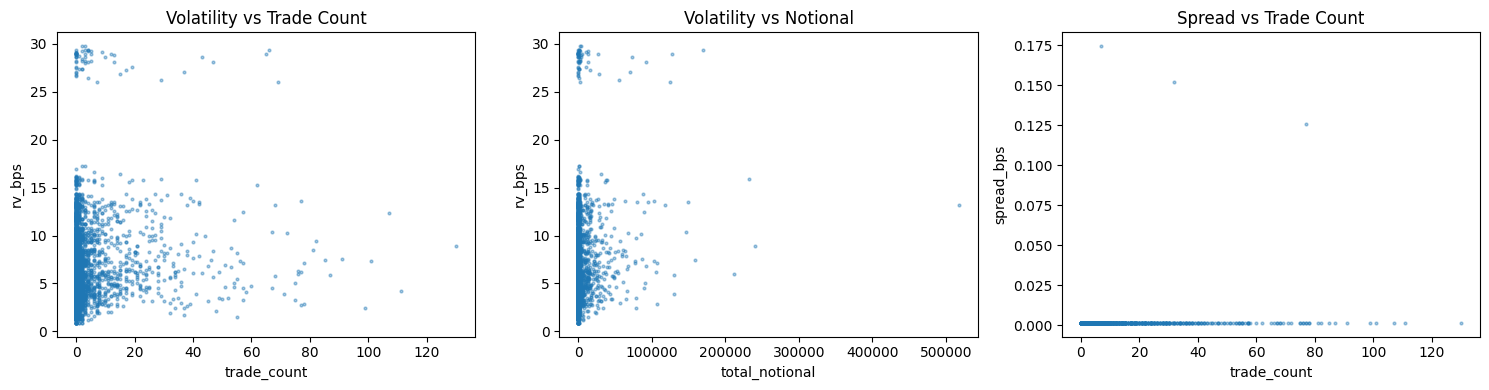

In [14]:
analysis_df = market_grid[["trade_count", "total_notional", "signed_notional", "spread_bps", "mid"]].copy()
analysis_df["rv_bps"] = rolling_rv_bps
analysis_df = analysis_df.dropna()
sample = analysis_df.iloc[::max(1, len(analysis_df) // 5000)].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(sample["trade_count"], sample["rv_bps"], s=4, alpha=0.4)
axes[0].set_title("Volatility vs Trade Count")
axes[0].set_xlabel("trade_count")
axes[0].set_ylabel("rv_bps")

axes[1].scatter(sample["total_notional"], sample["rv_bps"], s=4, alpha=0.4)
axes[1].set_title("Volatility vs Notional")
axes[1].set_xlabel("total_notional")
axes[1].set_ylabel("rv_bps")

axes[2].scatter(sample["trade_count"], sample["spread_bps"], s=4, alpha=0.4)
axes[2].set_title("Spread vs Trade Count")
axes[2].set_xlabel("trade_count")
axes[2].set_ylabel("spread_bps")
fig.tight_layout()

## Short Takeaways

In [15]:
median_spread = float(top_of_book["spread_bps"].median()) if not top_of_book.empty else np.nan
median_rv = float(rolling_rv_bps.median()) if not rolling_rv_bps.dropna().empty else np.nan
buy_share = float((trades["aggr_sign"] > 0).mean()) if not trades.empty else np.nan
signed_notional = float(trades["signed_notional"].sum()) if not trades.empty else np.nan

print(f"Day: {dataset.symbol} {dataset.day}")
print(f"Replay policy: {replay_info['replay_on_gap']} | kept {replay_info['segments_kept']} of {replay_info['segments_total']} segments")
print(f"Median spread: {median_spread:.4f} bps")
print(f"Median rolling realized vol ({vol_window}): {median_rv:.4f} bps")
print(f"Aggressive buy share: {buy_share:.3f}")
print(f"Net signed notional: {signed_notional:,.2f}")

Day: BTCUSDC 20260222
Replay policy: skip-segment | kept 1 of 1 segments
Median spread: 0.0015 bps
Median rolling realized vol (5min): 5.1512 bps
Aggressive buy share: 0.509
Net signed notional: 838,129.90
